In [1]:
# ======================================================
# Employee Attrition Prediction
# XYlofy AI Internship - Week 2
# Author: Sumit Banerjee
# ======================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("HR_Attrition.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
attrition_rate = (
    df["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(attrition_rate)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [9]:
numeric_columns = df.select_dtypes(include=["number"]).columns

categorical_columns = df.select_dtypes(include=["string", "object"]).columns

print("Numeric Columns :", len(numeric_columns))

print("Categorical Columns :", len(categorical_columns))

Numeric Columns : 26
Categorical Columns : 9


# ===============================
# Task 2 - Data Cleaning & Preprocessing
# ===============================

In [11]:
df = df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)

print("New Shape:", df.shape)

New Shape: (1470, 32)


In [12]:
df["Attrition"] = df["Attrition"].replace({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [21]:
categorical_columns = X.select_dtypes(
    include=["string","object"]
).columns

print(categorical_columns)

Index([], dtype='str')


In [19]:
# Target variable
y = df["Attrition"]

# Feature variables
X = df.drop("Attrition", axis=1)

# One-Hot Encoding only on feature columns
X = pd.get_dummies(X, drop_first=True)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1470, 45)
Target Shape: (1470,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (1470, 45)


# Task 3 - Exploratory Data Analysis (EDA)

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: object


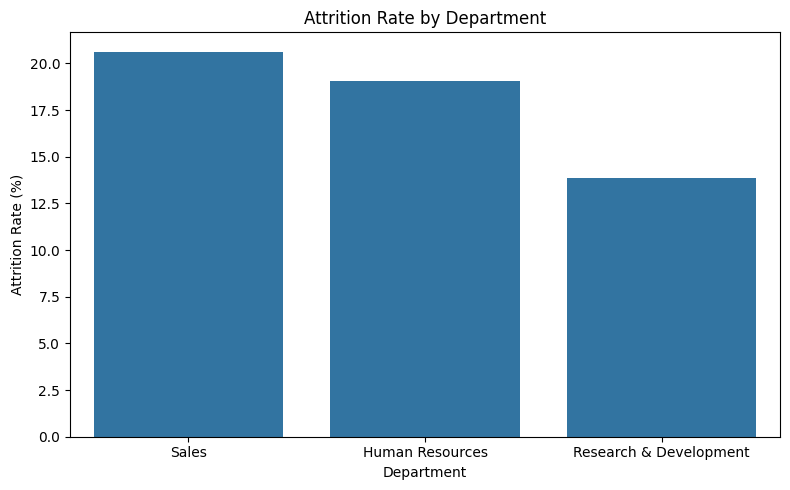

In [22]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

print(department_attrition)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/attrition_by_department.png")

plt.show()

### Observation

- The Sales department has the highest attrition rate (20.63%), indicating that employees in sales are more likely to leave the organization.
- Human Resources has the second-highest attrition rate (19.05%).
- Research & Development has the lowest attrition rate (13.84%), suggesting better employee retention compared to other departments.
- HR should prioritize employee retention initiatives in the Sales department to reduce turnover.

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist            16.1
Manufacturing Director         6.9
Healthcare Representative     6.87
Manager                        4.9
Research Director              2.5
Name: Attrition, dtype: object


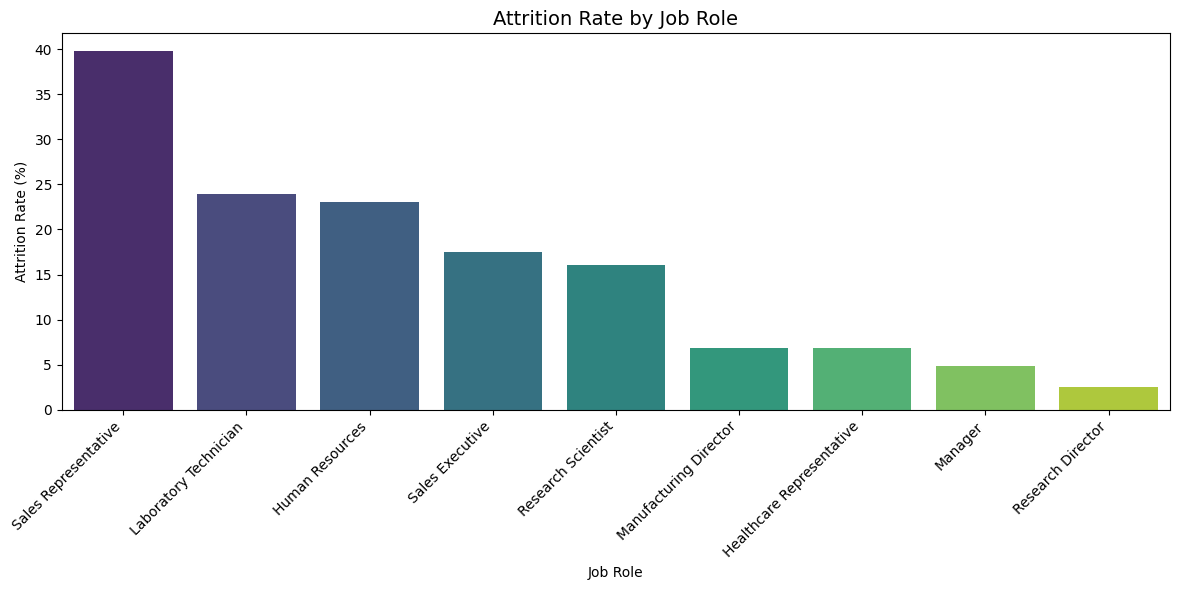

In [24]:
# Attrition Rate by Job Role

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

print(jobrole_attrition)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    hue=jobrole_attrition.index,
    palette="viridis",
    legend=False
)

plt.title("Attrition Rate by Job Role", fontsize=14)
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("charts/attrition_by_jobrole.png", dpi=300)

plt.show()

### Observation

- Sales Representatives have the highest attrition rate (39.76%), making them the most vulnerable group for employee turnover.
- Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also experience relatively high attrition.
- Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates, indicating stronger employee retention.
- HR should prioritize retention strategies for Sales Representatives and Laboratory Technicians, as these roles contribute the highest employee exits.

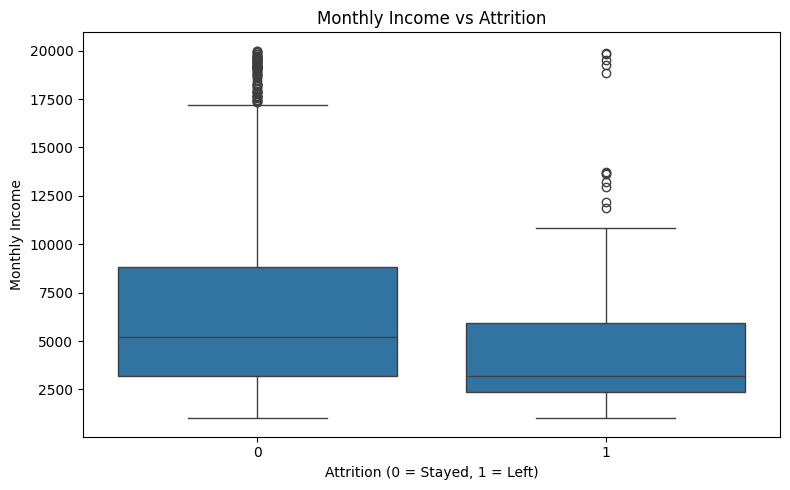

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/monthly_income_boxplot.png", dpi=300)

plt.show()

### Observation

- Employees who left the company generally have lower monthly incomes than those who stayed.
- The median monthly income of employees who stayed is noticeably higher.
- Although a few high-income employees also left the company, most attrition occurs among employees in the lower income range.
- This suggests that salary may influence employee attrition, but it is not the only factor affecting an employee's decision to leave.

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: object


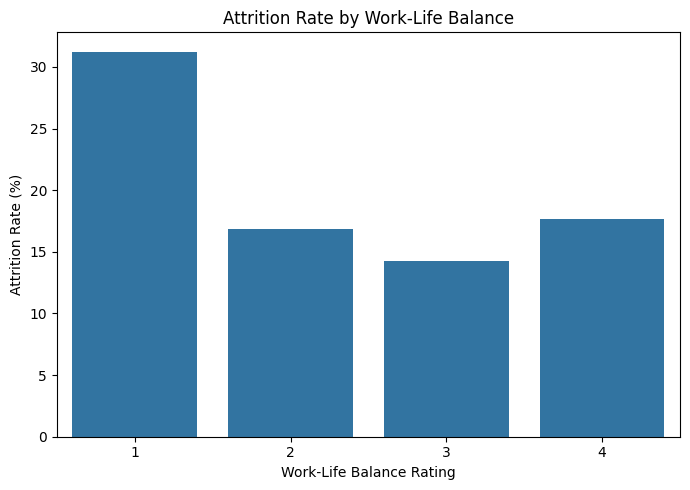

In [26]:
# Attrition Rate by Work-Life Balance

worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .mean()
      .mul(100)
      .round(2)
)

print(worklife_attrition)

plt.figure(figsize=(7,5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/worklife_balance.png", dpi=300)

plt.show()

### Observation

- Employees with the lowest Work-Life Balance rating (1) have the highest attrition rate (31.25%).
- Attrition decreases significantly as the Work-Life Balance rating improves.
- Employees with a Work-Life Balance rating of 3 have the lowest attrition rate (14.22%).
- These results suggest that improving employees' work-life balance may help reduce employee turnover and improve retention.

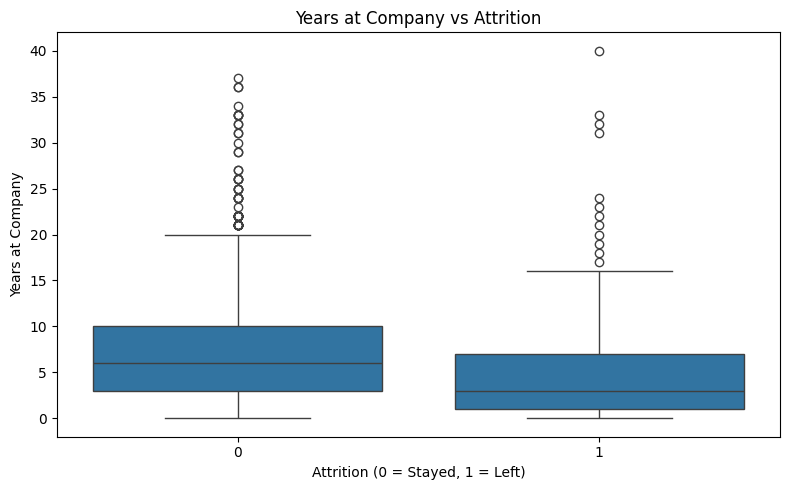

In [28]:
# Years at Company vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Years at Company")

plt.tight_layout()

plt.savefig("charts/years_at_company.png", dpi=300)

plt.show()

### Observation

- Employees who left the company generally have fewer years at the company compared to employees who stayed.
- The median years at the company is lower for employees who left, indicating that attrition is more common during the early years of employment.
- A few long-tenured employees also left the company, but they represent only a small portion of the workforce.
- This suggests that companies should focus on improving employee engagement and retention during the first few years of employment.

## Business Insights

1. The Sales department has the highest attrition rate (20.63%), indicating that it requires immediate attention from HR to improve employee retention.

2. Sales Representatives show the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%). These roles should be prioritized for retention programs.

3. Employees with the lowest Work-Life Balance rating (1) experience the highest attrition rate (31.25%), showing that work-life balance is an important factor influencing employee turnover.

4. Employees who leave the company generally earn lower monthly salaries than employees who stay, although salary alone does not fully explain attrition.

5. Most employees who leave have fewer years at the company, suggesting that organizations should strengthen onboarding, mentoring, and engagement programs during the first few years of employment.

# Task 4 - Model Building & Comparison

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1176, 45)
Testing Data  : (294, 45)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [32]:
# Ensure target column is numeric integer type
y = y.astype(int)

print(y.dtype)
print(y.value_counts())

int64
Attrition
0    1233
1     237
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1176, 45)
Testing Data  : (294, 45)


In [34]:
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [36]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [37]:
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


# Task 5 - Model Evaluation

In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

In [39]:
print("========== Logistic Regression ==========\n")

print(classification_report(y_test, log_pred))

log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_pred)

print("Precision :", round(log_precision,4))
print("Recall    :", round(log_recall,4))
print("F1 Score  :", round(log_f1,4))
print("ROC AUC   :", round(log_auc,4))

========== Logistic Regression ==========

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Precision : 0.3412
Recall    : 0.617
F1 Score  : 0.4394
ROC AUC   : 0.6952


In [40]:
print("========== Random Forest ==========\n")

print(classification_report(y_test, rf_pred))

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred)

print("Precision :", round(rf_precision,4))
print("Recall    :", round(rf_recall,4))
print("F1 Score  :", round(rf_f1,4))
print("ROC AUC   :", round(rf_auc,4))

========== Random Forest ==========

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.41      0.26      0.32        47

    accuracy                           0.82       294
   macro avg       0.64      0.59      0.61       294
weighted avg       0.80      0.82      0.81       294

Precision : 0.4138
Recall    : 0.2553
F1 Score  : 0.3158
ROC AUC   : 0.5932


In [41]:
print("========== Gradient Boosting ==========\n")

print(classification_report(y_test, gb_pred))

gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_pred)

print("Precision :", round(gb_precision,4))
print("Recall    :", round(gb_recall,4))
print("F1 Score  :", round(gb_f1,4))
print("ROC AUC   :", round(gb_auc,4))

========== Gradient Boosting ==========

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

Precision : 0.5882
Recall    : 0.2128
F1 Score  : 0.3125
ROC AUC   : 0.5922


In [42]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[
        log_precision,
        rf_precision,
        gb_precision
    ],
    "Recall":[
        log_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score":[
        log_f1,
        rf_f1,
        gb_f1
    ],
    "ROC AUC":[
        log_auc,
        rf_auc,
        gb_auc
    ]
})

comparison = comparison.round(4)

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.3412,0.6170,0.4394,0.6952
1,Random Forest,0.4138,0.2553,0.3158,0.5932
2,Gradient Boosting,0.5882,0.2128,0.3125,0.5922


<Figure size 600x500 with 0 Axes>

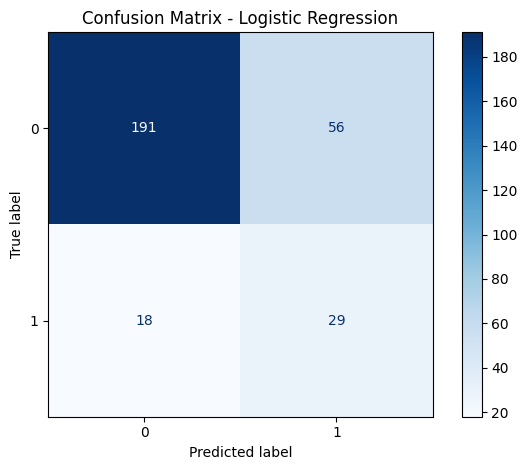

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig("charts/confusion_matrix.png", dpi=300)

plt.show()

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
35,JobRole_Laboratory Technician,0.797874
44,OverTime_Yes,0.766412
24,BusinessTravel_Travel_Frequently,0.719335
8,JobLevel,0.659189
17,TotalWorkingYears,0.656931
41,JobRole_Sales Representative,0.552515
25,BusinessTravel_Travel_Rarely,0.511649
28,EducationField_Life Sciences,0.506505
22,YearsSinceLastPromotion,0.500389
27,Department_Sales,0.481690


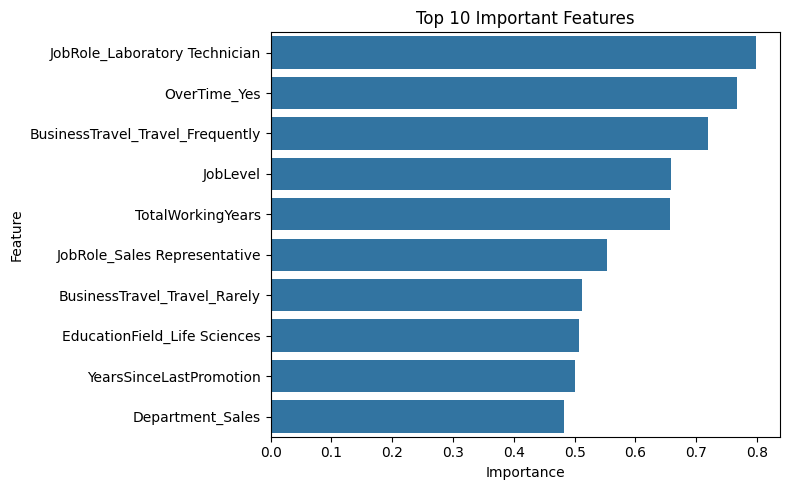

In [45]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("charts/top10_features.png", dpi=300)

plt.show()

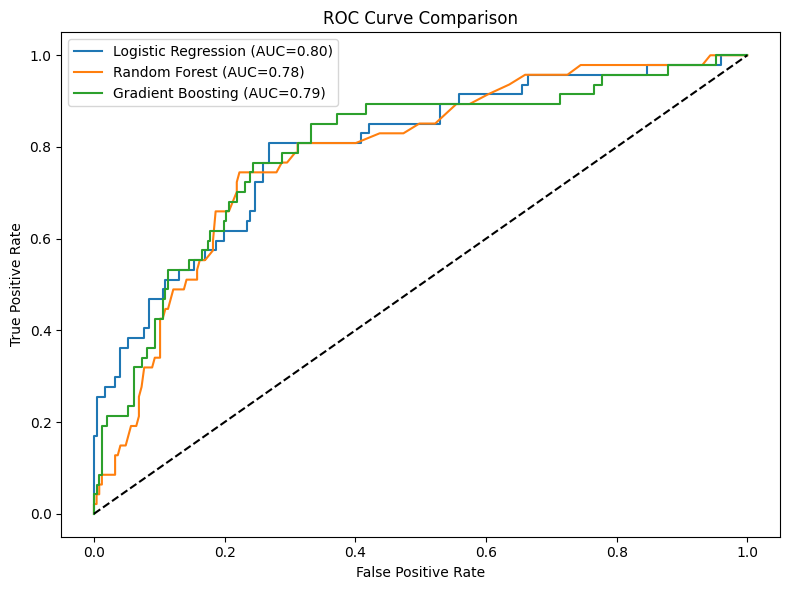

In [47]:
from sklearn.metrics import roc_curve, auc

# Probability scores
log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression (AUC={auc_log:.2f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={auc_rf:.2f})')

plt.plot(fpr_gb, tpr_gb,
         label=f'Gradient Boosting (AUC={auc_gb:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/roc_curve.png",dpi=300)

plt.show()

## Observation

The ROC Curve compares the performance of all three classification models.

Among the models, Logistic Regression achieved the highest ROC-AUC score (approximately 0.80), indicating the best overall ability to distinguish employees who are likely to leave from those who are likely to stay.

Random Forest and Gradient Boosting also performed reasonably well, with ROC-AUC scores around 0.78–0.79, but they were slightly less effective than Logistic Regression.

Therefore, Logistic Regression was selected as the best model for this employee attrition prediction task because it provided the best balance between identifying employees at risk of leaving and maintaining overall prediction performance.

# Task 7 - HR Insights & Business Recommendations

## HR Insights & Business Recommendations

### 1. Which three factors most strongly predict that an employee will leave?

Based on the feature importance analysis, the three strongest factors influencing employee attrition are:
- Job Role (especially Laboratory Technician and Sales Representative)
- Overtime (employees working overtime are more likely to leave)
- Frequent Business Travel

These factors showed the highest importance in predicting employee attrition.

---

### 2. Which department or job role should HR prioritize for retention efforts?

The Sales department has the highest attrition rate (20.63%). Among job roles, Sales Representatives and Laboratory Technicians experience the highest employee turnover. HR should prioritize these employees for retention programs and regular engagement.

---

### 3. Does salary alone explain attrition?

No. Although employees with lower monthly income tend to leave more frequently, salary is not the only reason for attrition. Factors such as overtime, business travel, job role, work-life balance, and career growth opportunities have a stronger influence on employee turnover.

---

### 4. HR Recommendations

- Conduct regular retention meetings with employees working in high-risk departments and job roles.
- Improve work-life balance by reducing excessive overtime and providing better career development opportunities, training, and promotion plans.

---

### 5. Model Limitation

This model is built using historical employee data and cannot capture personal reasons, family situations, external job opportunities, or economic conditions. Therefore, it should be used as a decision-support tool rather than the sole basis for HR decisions.